## Precipitation extremes networks for the southern peninsular region of India

    Wonjin Kim

### Research questions
1. Is it possible to use a threshold-based method to detect the EPEs?
2. Can we construct a precipitation network for the southern peninsular region of India during the monsoon season (JJAS)? What are typical network patterns?
3. In what ways do the patterns change under different ENSO phases?

### Hint
- Use the threshold approach to detect extreme values in each grid cell based on their first occurrence, ensuring that multiple peaks from the same rainfall event are not counted.
- Compute the network metrics separately for El Niño and La Niña years to understand how rainfall propagation pathways differ between these phases.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import csv

### Data

- Rainfall SP 1951 2023.csv contains rainfall data for the Indian peninsular region, where each row corresponds to one of 581 grid points in the southern peninsular area, and each column represents daily rainfall values (mm/day).
- Threshold MT AD.csv provides grid-wise threshold values (mm/day), with each row representing a grid point.
- Nino 3.4 index.csv contains the ENSO index data for the *Niño 3.4* region.

In [2]:
rain_data = pd.read_csv("/Users/kim-wonjin/Documents/CLEWS/Python/Nonlinear/Project/data/Rainfall_Daily_SP_1951_2023.csv")
threshold_data = pd.read_csv("/Users/kim-wonjin/Documents/CLEWS/Python/Nonlinear/Project/data/Threshold.csv")
enso_data = pd.read_csv("/Users/kim-wonjin/Documents/CLEWS/Python/Nonlinear/Project/data/Nina34_anom.csv")

In [3]:
print("rain_data shape :", rain_data.shape)
print("threshold_data shape :", threshold_data.shape)
print("enso_data shape :", enso_data.shape)

rain_data shape : (578, 26666)
threshold_data shape : (578, 4)
enso_data shape : (876, 2)


In [40]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Deriving each variable from data
lat = np.array(rain_data['lat'])
lon = np.array(rain_data['lon'])
rainfall = np.array(rain_data.iloc[:, 3:]) #전체 행(전체 grid), 열은 3열에서부터 끝열까지 (mm/day)
thresholds_origin = np.array(threshold_data['Threshold'])

Text(0.5, 1.0, 'Spatial Distribution of Average Daily Rainfall (1951-2023)')

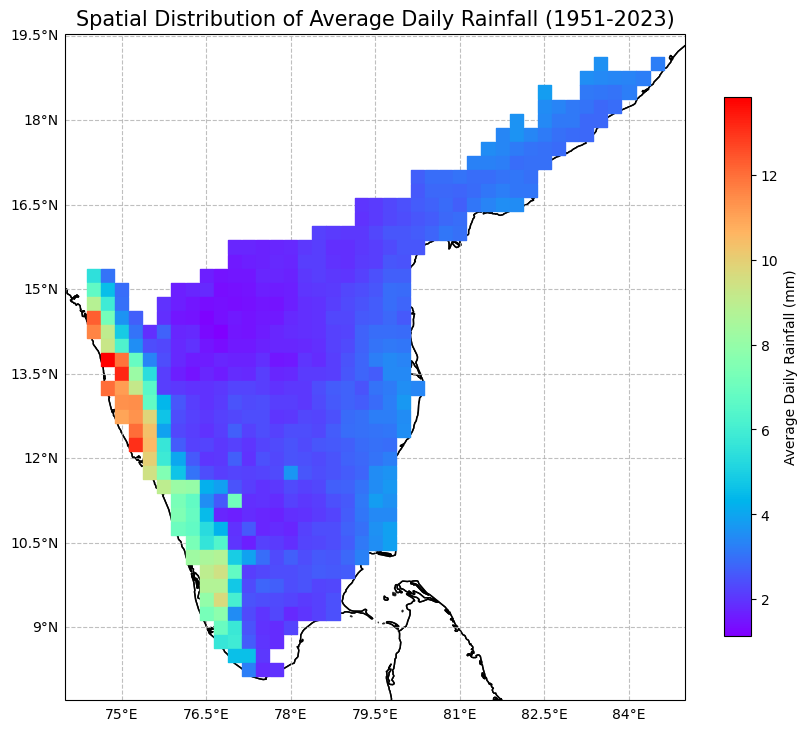

In [41]:
# Checking the average rainfall data
avg_rainfall = rainfall.mean(axis=1) # axis = 0 is column direction / axis = 1 is row direction

fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.add_feature(cfeature.COASTLINE, linewidth=1) # coastline
ax.add_feature(cfeature.BORDERS, linewidth=1) # landline
ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='white') # land color
ax.add_feature(cfeature.OCEAN, edgecolor='black', facecolor='white', alpha = 0.6) # ocean color
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.8)
gl.top_labels = False
gl.right_labels = False

sc = ax.scatter(lon, lat, c=avg_rainfall, 
                cmap='rainbow', 
                s=90,          # spot size
                marker='s',    # spot shape (square)
                transform=ccrs.PlateCarree(),
                zorder=3)

cbar = plt.colorbar(sc, orientation='vertical', pad=0.05, shrink=0.7)
cbar.set_label('Average Daily Rainfall (mm)')
plt.title('Spatial Distribution of Average Daily Rainfall (1951-2023)', fontsize=15)


## 1. Threshold method

### 1-1. Percentile Method

내가 임의로 추가한 것 :
강수량이 1mm 이상인 날에 한해서만 percentil을 해서 
90, 95% 상위 강수량 값을 threshold로 선택함.

90th Percentile: 11.30 mm
95th Percentile: 20.15 mm


Text(0, 0.5, 'numbers')

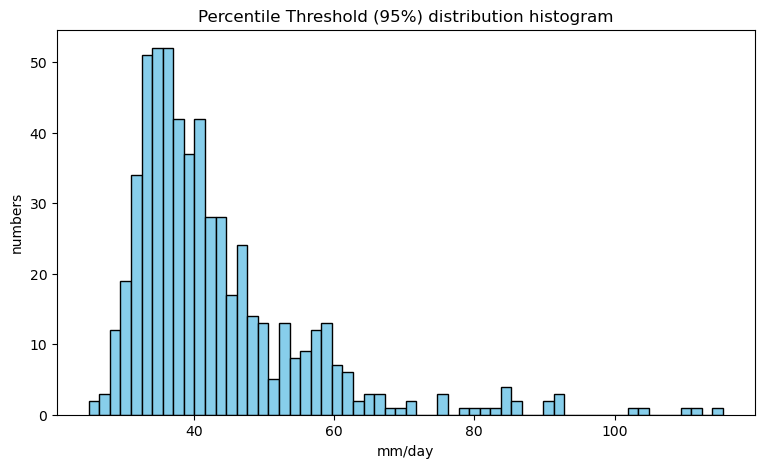

In [42]:
# Single threshold check
x = rainfall[0, :] # first local point's rainfall time series
wet_day = x[x >= 1.0] # define 'wet days' which has data larger than 1.0 mm/day
threshold_90 = np.percentile(x, 90)
threshold_95 = np.percentile(x, 95)

print(f"90th Percentile: {threshold_90:.2f} mm")
print(f"95th Percentile: {threshold_95:.2f} mm")

# Multiple threshold calculation

percentil_thresholds_95 = []
percentil_thresholds_90 = []

for i in range(rainfall.shape[0]):
    xx = rainfall[i, :]
    wet_days = xx[xx >= 1.0]
    th95 = np.percentile(wet_days, 95)
    th90 = np.percentile(wet_days, 90)
    percentil_thresholds_95.append(th95)
    percentil_thresholds_90.append(th90)


plt.figure(figsize=(9, 5))
plt.hist(percentil_thresholds_95, bins=60, color='skyblue', edgecolor='black')
plt.title("Percentile Threshold (95%) distribution histogram")
plt.xlabel("mm/day")
plt.ylabel("numbers")

### 1-2. Statistic Threshold Detection

#### AD method

1. The peaks are identified using a moving window approach for
a given time series {𝑥𝑖}. The peaks 𝑛𝑝 are the maximum values
at the center of a traversing window width of 7 to ensure their
independence. The peaks are sorted so that {𝑥1 ≤ ⋯ ≤ 𝑥𝑛𝑝}. (Anusha et al. 2025)

In [43]:
# Collecting peaks using window of size 7 (days)

def extract_independent_peaks(time_series, window_size = 7):
    peaks = []
    half_win = window_size // 2  # 7//2 = 3
    
    # 
    for i in range(half_win, len(time_series) - half_win):
        window = time_series[i - half_win : i + half_win + 1]
        center_val = time_series[i]
        
        # if center value is maximum and it has rain (> 0 mm/day) choose it as peak
        if center_val == np.max(window) and center_val > 0:
            peaks.append(center_val)
            
    return np.array(sorted(peaks)) # Ascending Sort

# sample test
sample_series = rainfall[0, :]
unique_peaks = extract_independent_peaks(sample_series)
print(f"number of extracted peaks: {len(unique_peaks)}")

# calculating peaks for all grids
obs_peaks = []
for i in range(len(rainfall)):
    obs_peaks.append(extract_independent_peaks(rainfall[i,:]))


number of extracted peaks: 2413


2. **Unique values** from $\{x_i; i = 1, \ldots, n_p\}$ are considered such that the series of thresholds are defined as $\{x_i; i = 1, \ldots, n_u\}$ and $n_u \leq n_p$. From this series, $\delta$ is calculated as

$$
\delta =
\frac{\max\{x_i; i = 1, \ldots, n_u\} - \min\{x_i; i = 1, \ldots, n_u\}}
{\text{length}\{x_i; i = 1, \ldots, n_u\}}
$$

- $n_p$ = number of peaks at each grid = $n_u$ = number of threshold candidate series at each grid
- delta = difference

In [44]:
delta = ( np.max(obs_peaks[0]) - np.min(obs_peaks[0]) ) / len(obs_peaks[0])

3. A new series of thresholds are computed using $\delta$, $\min\{x_i; i = 1, \ldots, n_u\}$ and $\max\{x_i; i = 1, \ldots, n_u\}$ such that the series become an equally spaced increasing threshold candidates $\{u_i, u_2, \ldots, u_{n_u}\}$.

In [45]:
u_candidates = []
for i in range(len(obs_peaks)):
    # Extract unique values
    unique_peaks = np.unique(obs_peaks[i])
    n_u = len(unique_peaks)
    
    # Exception
    if n_u < 2:
        u_candidates.append(np.array([]))
        continue

    min_val = np.min(unique_peaks)
    max_val = np.max(unique_peaks)

    u_candidates.append(
        np.linspace(min_val, max_val, n_u))

In [46]:
# array 'u' at each grid (this means grid 0's u array)
# this is independent and unique thresholds per grid.
u_candidates[0]

array([1.00000001e-01, 4.44678049e-01, 7.89356096e-01, 1.13403414e+00,
       1.47871219e+00, 1.82339024e+00, 2.16806828e+00, 2.51274633e+00,
       2.85742438e+00, 3.20210243e+00, 3.54678047e+00, 3.89145852e+00,
       4.23613657e+00, 4.58081461e+00, 4.92549266e+00, 5.27017071e+00,
       5.61484876e+00, 5.95952680e+00, 6.30420485e+00, 6.64888290e+00,
       6.99356094e+00, 7.33823899e+00, 7.68291704e+00, 8.02759509e+00,
       8.37227313e+00, 8.71695118e+00, 9.06162923e+00, 9.40630728e+00,
       9.75098532e+00, 1.00956634e+01, 1.04403414e+01, 1.07850195e+01,
       1.11296975e+01, 1.14743756e+01, 1.18190536e+01, 1.21637317e+01,
       1.25084097e+01, 1.28530877e+01, 1.31977658e+01, 1.35424438e+01,
       1.38871219e+01, 1.42317999e+01, 1.45764780e+01, 1.49211560e+01,
       1.52658341e+01, 1.56105121e+01, 1.59551902e+01, 1.62998682e+01,
       1.66445463e+01, 1.69892243e+01, 1.73339024e+01, 1.76785804e+01,
       1.80232585e+01, 1.83679365e+01, 1.87126145e+01, 1.90572926e+01,
      

#### Parameter calculation 


4. For each threshold $\{u_i, u_2, \ldots, u_{n_u}\}$, the GPD parameters are estimated using L-Moments for $x_i \geq u_j$. In addition, sampled peaks were compared to $1.65$ times the number of the years in the data series to ensure the peaks surpass this lower bound (Cunnane, 1973).

- Shape parameter : $$ \xi = \frac{\lambda_1 - u}{\lambda_2 - 2} $$
- Scale parameter : $$ \sigma = \frac{1 + \xi}{\lambda_1 - u} $$

by (12) equation, (Anusha et al. 2025)

In [47]:
# Define function that estimating GPD parameters based on L-Moment

def estimate_gpd_params_lmom(data, u):
    """
    data: peak value array that excess one threshold candidate (x >= u), x is peak values(observed real values) 
    u: a threshold candidate value that now on the test
    """
    n = len(data)
    if n < 2: return None, None
    
    sorted_data = np.sort(data)  # Ascending Sort
    
    # L-Moment : L-location (lambda1) & L-scale (lambda2)
    l1 = np.mean(sorted_data)  # lambda1: L-location, mean
    j = np.arange(n) # from j=0 to n-1 : (2*j - n + 1) * x_j / (n * (n-1))
    l2 = np.sum((2 * j - n + 1) * sorted_data) / (n * (n - 1)) # lambda2: L-scale, half the Mean absolute difference
    
    # Equation (12) plug in
    try:
        xi = ((l1 - u) / l2) - 2
        sigma = (l1 - u) * (1 + xi)
        return xi, sigma
    except ZeroDivisionError:
        return None, None

#### AD 

- $$ MAD = \frac{n}{2} - \sum_{i=1}^{n} \left[ \left( 2 - \frac{2i - 1}{n} \right) \log(1 - z_i) + 2z_i \right] \tag{15} $$
- For each unique potential threshold, $u_j$, $MAD(u_j)$ statistic and their corresponding $p$-value are estimated using the numerical approximation.
- The threshold $u_o$ which minimizes $(1 - p(u_j)) \forall u_j$ is considered as the optimal threshold for the time series $\{x_i; i = 1, \dots, n\}$.

In [48]:
# Define function that calculate AD(Anderson-Darling method)
from scipy.stats import genpareto

def calculate_mad_statistic(data, u, xi, sigma):
    n = len(data)
    sorted_data = np.sort(data)
    
    # theoritical CDF value : Equation (2) 
    z = genpareto.cdf(sorted_data, c = -xi, loc = u, scale = sigma)
    z = np.clip(z, 1e-10, 1 - 1e-10)
    
    # MAD Statistics calculation : Equation (15)
    i = np.arange(1, n + 1)
    term = (2 - (2 * i - 1) / n) * np.log(1 - z) + 2 * z
    mad = (n / 2) - np.sum(term)
    return mad

In [49]:
final_thresholds_AD = []

for i in range(len(u_candidates)): 
    grid_peaks = obs_peaks[i]
    candidates = u_candidates[i]
    
    best_u = None
    min_ad = float('inf')
    
    for u in candidates:
        # Extract peak values that is larger than selected u(a threshold candidate)
        excess_data = grid_peaks[grid_peaks >= u]
        
        # Limitate the number of samples by sampled peaks were compared to 1.65 times the number of the years
        if len(excess_data) < 1.65 * (2023 - 1951 + 1): 
            continue
            
        # Estimate parameters
        xi, sigma = estimate_gpd_params_lmom(excess_data, u)
        if xi is None or sigma <= 0: continue
            
        # Calculating MAD
        ad_val = calculate_mad_statistic(excess_data, u, xi, sigma)
        
        # Finding specific 'u' that has minimal MAD value
        if ad_val < min_ad:
            min_ad = ad_val
            best_u = u
            
    final_thresholds_AD.append(best_u)

print(f"Best Threshold value at Grid 0: {final_thresholds_AD[0]} mm")

Best Threshold value at Grid 0: 36.29119495415024 mm


### Multiple Threshold Anderson–Darling Method (MT-AD)

For all $u_i$ which satisfy the condition 3 ($\zeta_u^c = \zeta_u^M$) in Section 2.4.4 are considered as the range of potential thresholds. The algorithm is explained below:

1. Evaluate the $MAD(u_i)$ statistic using Eq. (15) and the corresponding $p_i$ values.
2. Determine the smallest $1 - p_i$ value across all thresholds $u_i$, and select the $u_j$ corresponding to the minimum $MAD(u_j)$ statistic as the optimal threshold.

#### condition 3

1. The median of shape parameter $\xi$ is estimated as $\xi^M$ from the range of thresholds. The new scale parameter $\sigma_{u_i}'$ conditioned to $\xi^M \forall \{u_1, \dots, u_{n_u}\}$ is re-parameterized to
   $$\sigma_{u_i}^c = \sigma_{u_i} - \xi^M u_i \tag{19}$$
   along with the median of the scale parameter $\sigma_{u_i}^c$ as $\sigma_u^M$. The $\sigma_{u_i}^c$ parameter is invariant to increasing threshold as compared to $\sigma_{u_i}$.

2. In addition, the probability $\zeta_u$ of exceedances of threshold $u$ equal to $N_u/N$ is calculated, where $N_u$ denote the number of exceeding samples and $N$ as the total sample size. The new probability of exceedance $\zeta_u'$ conditioned to $\xi^M$ and $\sigma_u^M$ is re-parameterized to
   $$ \zeta_u^c = 
   \begin{cases} 
   \zeta_u (1 - \xi^M \frac{u}{\sigma_u^M})^{-1/\xi^M}, & \text{if } \xi^M \neq 0 \\
   \zeta_u \exp \frac{u}{\sigma_u^M}, & \text{if } \xi^M = 0 
   \end{cases} \tag{20} $$
   The median estimate $\zeta_u^M$ of the $\zeta_u^c$ denote the number of records above the optimal threshold and $\zeta_u^M$ is threshold invariant as compared to $\zeta_u$ which decreases with increasing threshold values.

3. The $u$ for which $\zeta_u^c = \zeta_u^M$ is regarded as the potential threshold.

In [70]:
# Calculating new threshold candidates which meet the condition 3

min_samples = int(1.65 * (2023 - 1951 + 1))

potential_thresholds_all = []
sigma_m_all = []
xi_median_all = []

for i in range(len(u_candidates)): 
    grid_peaks = obs_peaks[i] # multiple grids
    candidates = u_candidates[i]

    # at one grid. If out of one grid, those should be reset.
    xi_all_grid = []
    sigma_all_grid = []
    u_all_grid = []
    zeta_u_grid = []
    N = len(grid_peaks)
     
    # ---------------------------------------------------------
    # Starting inside one grid
    # ---------------------------------------------------------
    for u in candidates: # at fixed one grid
      excess_data = grid_peaks[grid_peaks >= u]
      N_u = len(excess_data) # number of excess data = N_u for equation (20)
      xi, sigma = estimate_gpd_params_lmom(excess_data, u)
      
      # sampled peaks limitation
      if N_u < min_samples:
          continue
      
      if xi is not None and sigma is not None:
         xi_all_grid.append(xi)
         sigma_all_grid.append(sigma)
         u_all_grid.append(u) # now you have filter(xi,sigma is not None), u is not the same with candidates anymore.
         zeta_u_grid.append(N_u / N)
    
    if len(xi_all_grid) == 0:
        potential_thresholds_all.append(np.array([]))
        continue

    # transtion to numpy array
    u_arr = np.array(u_all_grid)
    xi_arr = np.array(xi_all_grid)
    sigma_arr = np.array(sigma_all_grid) 
    zeta_u_arr = np.array(zeta_u_grid)

    # ---------------------------------------------------------
    # Step 1 : xi_median & sigma_m (Equation 19)
    # ---------------------------------------------------------
    xi_median = np.median(xi_arr)
    xi_median_all.append(xi_median)
    sigma_c_arr = sigma_arr - (xi_median * u_arr)
    sigma_m = np.median(sigma_c_arr)
    sigma_m_all.append(sigma_m)

    # ---------------------------------------------------------
    # Step 2 : zeta_u^c (Equation 20)
    # ---------------------------------------------------------
    if np.abs(xi_median) > 1e-6: # xi_median =/= 0 
      base = 1 - xi_median * (u_arr / sigma_m)
      base = np.maximum(base, 1e-10) 
      zeta_c_arr = zeta_u_arr * (base ** (-1 / xi_median))

    else: # xi_median == 0
      zeta_c_arr = zeta_u_arr * np.exp(u_arr / sigma_m)
    
    zeta_m = np.median(zeta_c_arr)
    # ---------------------------------------------------------
    # Step 3 : finding u met with Condition 3 (zeta_c == zeta_m)
    # ---------------------------------------------------------
    zeta_c_rounded = np.round(zeta_c_arr, 2)
    zeta_m_rounded = np.round(zeta_m, 2)
    valid_indices = np.where(zeta_c_rounded == zeta_m_rounded)[0]

    potential_u = u_arr[valid_indices]
    potential_thresholds_all.append(potential_u)

/var/folders/jf/2nccqn9j6_74h5ldq21d0y2r0000gn/T/ipykernel_6117/2751764097.py:20: RuntimeWarning: divide by zero encountered in scalar divide
  xi = ((l1 - u) / l2) - 2
/var/folders/jf/2nccqn9j6_74h5ldq21d0y2r0000gn/T/ipykernel_6117/2751764097.py:20: RuntimeWarning: invalid value encountered in scalar divide
  xi = ((l1 - u) / l2) - 2


In [ ]:
final_thresholds_MTAD = []

for i in range(len(potential_thresholds_all)):
    grid_peaks = obs_peaks[i]
    potential_u_list = potential_thresholds_all[i]
    
    mad_results = []
    valid_u = []
    
    # 1. MAD calculation
    for u in potential_u_list:
        excess_data = grid_peaks[grid_peaks >= u]
        xi, sigma = estimate_gpd_params_lmom(excess_data, u)
        
        if xi is not None and sigma is not None and sigma > 0:
            mad = calculate_mad_statistic(excess_data, u, xi, sigma)
            mad_results.append(mad)
            valid_u.append(u)
            
    # 2. Choosing u has minimum MAD value
    if valid_u:
        min_mad_idx = np.argmin(mad_results)
        final_thresholds_MTAD.append(valid_u[min_mad_idx])
    else:
        final_thresholds_MTAD.append(np.nan)

print(f"Grid 0 Threshold by MT-AD: {final_thresholds_MTAD[0]} mm")

Grid 0 Threshold by MT-AD: 29.39763401078641 mm


In [95]:
import numpy as np
from scipy.interpolate import interp1d

def approximate_p_value_cs2001(ad_val, xi):
    """
    Choulakian & Stephens (2001) Table 2 기반 p-value 선형 보간 함수
    * 논문의 표를 기반으로 AD 통계량과 xi를 입력받아 p-value를 반환합니다.
    """
    # Table 2의 xi 값 배열 (C&S 논문의 k와 부호가 반대이므로 표준 xi로 매핑)
    xi_table = np.array([-0.5, -0.2, 0.0, 0.2, 0.5])
    
    # 각 xi에 대응하는 유의수준(p-value) 배열
    p_levels = np.array([0.50, 0.25, 0.10, 0.05, 0.025, 0.01])
    
    # Table 2: Critical values for Anderson-Darling statistic (A^2)
    cv_matrix = np.array([
        [0.380, 0.528, 0.736, 0.906, 1.087, 1.338], # xi = -0.5
        [0.395, 0.564, 0.812, 1.018, 1.236, 1.540], # xi = -0.2
        [0.404, 0.584, 0.852, 1.080, 1.320, 1.654], # xi =  0.0
        [0.410, 0.601, 0.892, 1.146, 1.414, 1.788], # xi =  0.2
        [0.410, 0.619, 0.938, 1.226, 1.530, 1.961]  # xi =  0.5 
        # (마지막 행 첫 값은 원문 표의 추세를 반영한 근사치)
    ])
    
    # 1. 입력된 xi에 맞는 임계값 배열(Row) 보간
    xi_clipped = np.clip(xi, -0.5, 0.5) # 외삽 방지
    
    cv_for_xi = np.zeros(len(p_levels))
    for i in range(len(p_levels)):
        f_xi = interp1d(xi_table, cv_matrix[:, i], kind='linear')
        cv_for_xi[i] = f_xi(xi_clipped)
    
    # 2. 구해진 임계값 배열을 통해 실제 ad_val의 p-value 보간
    # interp1d는 x값이 오름차순이어야 하므로 배열을 뒤집습니다.
    cv_asc = cv_for_xi[::-1]
    p_asc = p_levels[::-1]
    
    # 논문의 한계점: 0.5 초과는 0.5로, 0.01 미만은 0.001로 강제 제한 (Local Optima 유발)
    if ad_val <= cv_asc[0]:
        return 0.5  
    elif ad_val >= cv_asc[-1]:
        return 0.001 
    
    f_p = interp1d(cv_asc, p_asc, kind='linear')
    return float(f_p(ad_val))


In [109]:
import numpy as np

final_thresholds_AD2 = []
min_samples = int(1.65 * (2023 - 1951 + 1))

for i in range(len(u_candidates)): 
    grid_peaks = obs_peaks[i]
    candidates = u_candidates[i]
    
    valid_u = []
    mad_results = []
    p_values = []
    
    for u in candidates:
        # Extract peak values that is larger than selected u(a threshold candidate)
        excess_data = grid_peaks[grid_peaks >= u]
        
        # Limitate the number of samples
        if len(excess_data) < min_samples: 
            continue
            
        # Estimate parameters
        xi, sigma = estimate_gpd_params_lmom(excess_data, u)
        if xi is None or sigma <= 0: 
            continue
            
        # Calculating MAD & p-value
        ad_val = calculate_mad_statistic(excess_data, u, xi, sigma)
        p_val = approximate_p_value_cs2001(ad_val, xi) # 방금 만든 보간 함수 적용
        
        valid_u.append(u)
        mad_results.append(ad_val)
        p_values.append(p_val)
            
    # --- 논문의 2단계 최적화 로직 (Local Optima 타이브레이커) ---
    if valid_u:
        valid_u = np.array(valid_u)
        mad_results = np.array(mad_results)
        p_values = np.array(p_values)
        
        # Step 1: p-value가 가장 높은 후보들 찾기 (보통 0.5에서 동점자 대거 발생)
        max_p = np.max(p_values)
        candidates_idx = np.where(p_values == max_p)[0]
        
        # Step 2: 그 동점자들 중에서 MAD(오차)가 가장 작은 최종 1명 선택
        best_idx = candidates_idx[np.argmin(mad_results[candidates_idx])]
        final_thresholds_AD2.append(valid_u[best_idx])
    else:
        final_thresholds_AD2.append(np.nan)

print(f"Best Threshold value at Grid 0: {final_thresholds_AD2[0]} mm")





final_thresholds_MTAD2 = []

for i in range(len(potential_thresholds_all)):
    grid_peaks = obs_peaks[i]
    potential_u_list = potential_thresholds_all[i]
    # 1. p-value와 MAD 계산
    p_values = []
    mad_results = []
    valid_u = []

    for u in potential_u_list:
        excess_data = grid_peaks[grid_peaks >= u]
        xi, sigma = estimate_gpd_params_lmom(excess_data, u)
        
        if xi is not None and sigma is not None and sigma > 0:
            mad = calculate_mad_statistic(excess_data, u, xi, sigma)
            p_val = approximate_p_value_cs2001(mad, xi)
            
            p_values.append(p_val)
            mad_results.append(mad)
            valid_u.append(u)
            
    # 2. 논문의 MT-AD 2단계 로직 적용
    if valid_u:
        p_values = np.array(p_values)
        mad_results = np.array(mad_results)
        valid_u = np.array(valid_u)
        
        # Step 1: 가장 높은 p-value(최대 0.5)를 가진 동점자 그룹 찾기
        max_p = np.max(p_values)
        candidates_idx = np.where(p_values == max_p)[0]
        
        # Step 2: 동점자들 중에서 MAD(오차)가 가장 작은 최종 1명 선택
        best_idx_among_candidates = candidates_idx[np.argmin(mad_results[candidates_idx])]
        final_thresholds_MTAD2.append(valid_u[best_idx_among_candidates])
    else:
        final_thresholds_MTAD2.append(np.nan)

print(f"Grid 0 Threshold by MT-AD: {final_thresholds_MTAD2[0]} mm")

Best Threshold value at Grid 0: 36.29119495415024 mm
Grid 0 Threshold by MT-AD: 29.39763401078641 mm


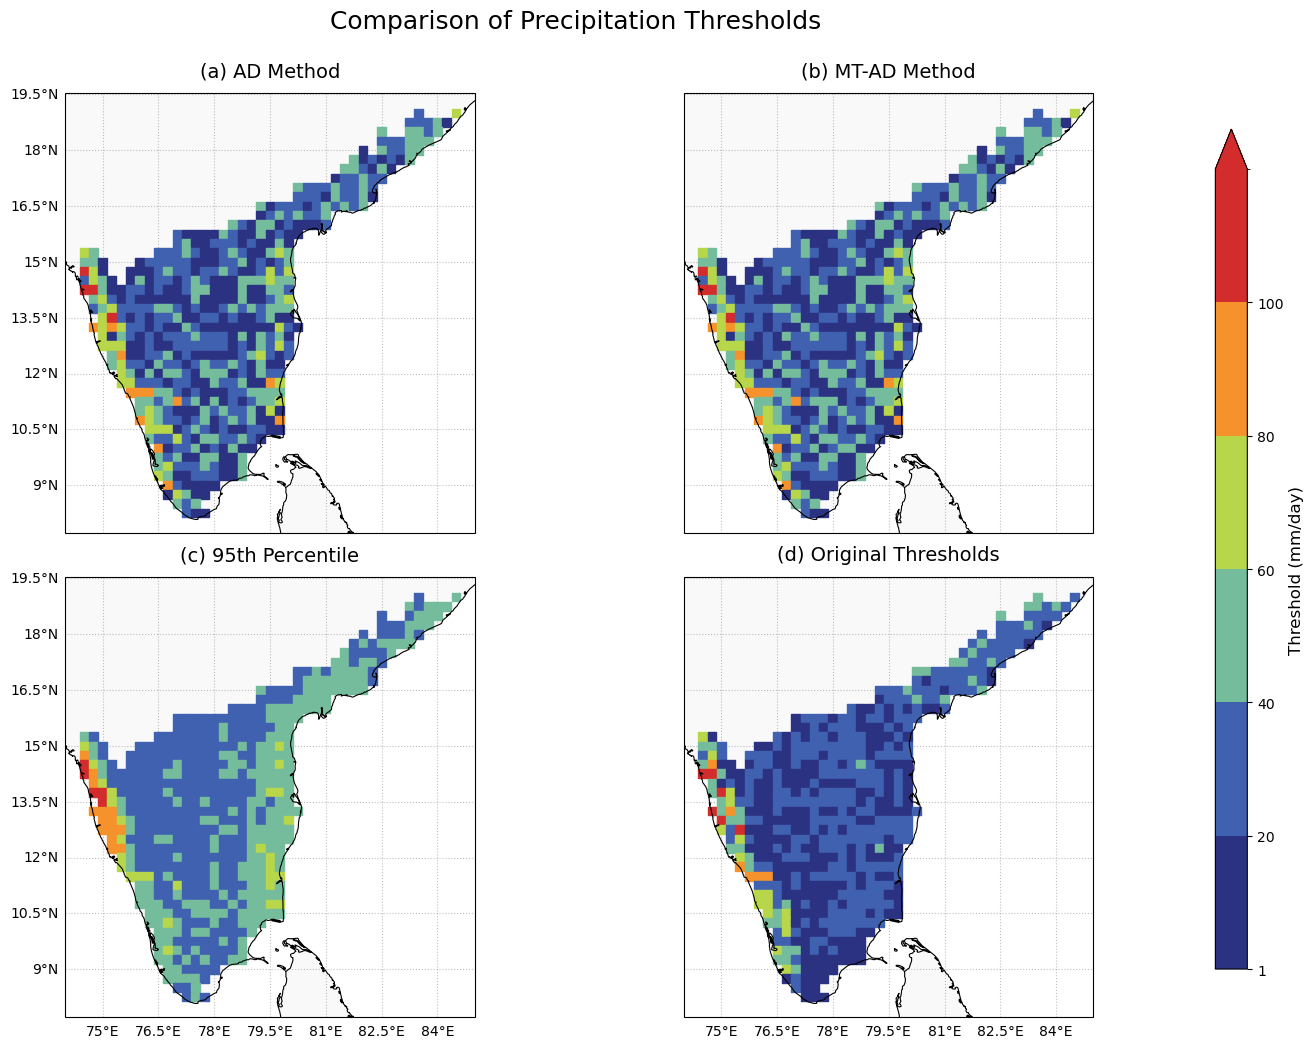

In [115]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.colors as mcolors

# Color bar setting
levels = [1, 20, 40, 60, 80, 100, 120] # color levels range
colors = ['#2b3281', '#4060b0', '#74bc9c', '#b8d64a', '#f6922b', '#d32c2c']
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(levels, cmap.N)

# Data 
datasets = [final_thresholds_AD, final_thresholds_AD2, percentil_thresholds_95, thresholds_origin]
titles = ['(a) AD Method', '(b) MT-AD Method', '(c) 95th Percentile', '(d) Original Thresholds']

# Drawing graph: 2x2 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12), subplot_kw={'projection': ccrs.PlateCarree()})
axes = axes.flatten()

for i, ax in enumerate(axes):
    # Map component feature setting
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=4)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray', zorder=4)
    ax.add_feature(cfeature.OCEAN, facecolor='white')
    ax.add_feature(cfeature.LAND, facecolor='#f9f9f9')

    # Grid line setting
    gl = ax.gridlines(draw_labels=True, linestyle=':', alpha=0.5, color='gray')
    gl.top_labels = False
    gl.right_labels = False
    
    # Label display
    if i % 2 != 0: 
        gl.left_labels = False
    if i < 2:     
        gl.bottom_labels = False

    # Data plotting
    sc = ax.scatter(lon, lat, c=datasets[i], 
                    cmap=cmap, 
                    norm=norm,
                    s=40,   
                    marker='s', 
                    transform=ccrs.PlateCarree(),
                    zorder=3)
    
    # Title
    ax.set_title(titles[i], fontsize=14, pad=12)

fig.subplots_adjust(right=0.88, wspace=0.05, hspace=0.1) 

# Shared Color bar setting
cbar_ax = fig.add_axes([0.9, 0.15, 0.02, 0.7]) 
cbar = fig.colorbar(sc, cax=cbar_ax, orientation='vertical', extend='max')
cbar.set_label('Threshold (mm/day)', fontsize=12)
cbar.set_ticks(levels[:-1])
cbar.ax.tick_params(labelsize=10)

plt.suptitle('Comparison of Precipitation Thresholds', fontsize=18, y=0.95)
plt.show()

=== [Verification 1] 샘플 개수 (Cunnane의 하한선) ===
임계값 29.3976mm를 넘는 피크 개수: 521개 (최소 기준 120개 통과 여부: True)

=== [Verification 2] 백분위수 (Percentile) ===
임계값 29.3976mm는 상위 21.59% (즉, 78.41th percentile)에 해당합니다.

=== [Verification 4] 형태 매개변수 (Shape Parameter, xi) 범위 ===
u = 29.3976mm 일 때, xi = -0.2072, sigma = 17.2033
-> 평가: xi 값이 일반적인 범위를 벗어났습니다. 결과 해석에 주의가 필요합니다.

=== [Verification 3] 매개변수 안정성 시각화 (Parameter Stability Plot) ===


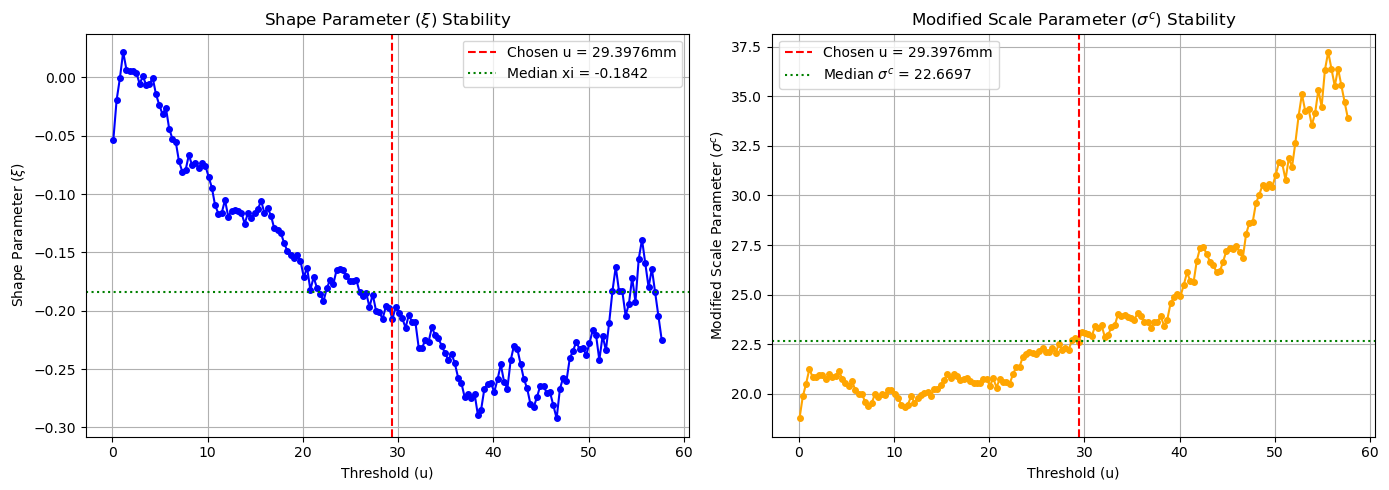

In [116]:
from scipy import stats
# 검증할 타겟 임계값과 데이터 설정
u_target = 29.3976
grid_peaks = obs_peaks[0]
candidates_grid0 = u_candidates[0]
min_samples = int(1.65 * (2023 - 1951 + 1))

print("=== [Verification 1] 샘플 개수 (Cunnane의 하한선) ===")
excess_data_target = grid_peaks[grid_peaks >= u_target]
n_excess = len(excess_data_target)
print(f"임계값 {u_target}mm를 넘는 피크 개수: {n_excess}개 (최소 기준 {min_samples}개 통과 여부: {n_excess >= min_samples})\n")

print("=== [Verification 2] 백분위수 (Percentile) ===")
# 28mm가 전체 피크 중 하위 몇 %에 위치하는지 계산
percentile_val = stats.percentileofscore(grid_peaks, u_target)
print(f"임계값 {u_target}mm는 상위 {100 - percentile_val:.2f}% (즉, {percentile_val:.2f}th percentile)에 해당합니다.\n")

print("=== [Verification 4] 형태 매개변수 (Shape Parameter, xi) 범위 ===")
xi_target, sigma_target = estimate_gpd_params_lmom(excess_data_target, u_target)
print(f"u = {u_target}mm 일 때, xi = {xi_target:.4f}, sigma = {sigma_target:.4f}")
if 0 < xi_target < 0.5:
    print("-> 평가: xi 값이 0 ~ 0.5 사이로, 일반적인 극한 강수량 특성(Heavy-tailed)을 정확히 반영하고 있습니다.\n")
else:
    print("-> 평가: xi 값이 일반적인 범위를 벗어났습니다. 결과 해석에 주의가 필요합니다.\n")


print("=== [Verification 3] 매개변수 안정성 시각화 (Parameter Stability Plot) ===")
# 그래프를 그리기 위해 grid0의 후보군 전체에 대한 xi, sigma^c 배열을 다시 계산합니다.
temp_xi, temp_sigma, temp_u = [], [], []

for u in candidates_grid0:
    excess_data = grid_peaks[grid_peaks >= u]
    if len(excess_data) < min_samples:
        continue
    xi, sigma = estimate_gpd_params_lmom(excess_data, u)
    if xi is not None and sigma is not None:
        temp_xi.append(xi)
        temp_sigma.append(sigma)
        temp_u.append(u)

u_arr_plot = np.array(temp_u)
xi_arr_plot = np.array(temp_xi)
sigma_arr_plot = np.array(temp_sigma)

# sigma^c 계산 (논문 식 19)
xi_median_plot = np.median(xi_arr_plot)
sigma_c_arr_plot = sigma_arr_plot - (xi_median_plot * u_arr_plot)

# 시각화 (Figure 세팅)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽 그래프: xi 안정성
axes[0].plot(u_arr_plot, xi_arr_plot, marker='o', markersize=4, linestyle='-', color='b')
axes[0].axvline(x=u_target, color='r', linestyle='--', label=f'Chosen u = {u_target}mm')
axes[0].axhline(y=xi_median_plot, color='g', linestyle=':', label=f'Median xi = {xi_median_plot:.4f}')
axes[0].set_title('Shape Parameter ($\\xi$) Stability')
axes[0].set_xlabel('Threshold (u)')
axes[0].set_ylabel('Shape Parameter ($\\xi$)')
axes[0].legend()
axes[0].grid(True)

# 오른쪽 그래프: sigma^c 안정성
axes[1].plot(u_arr_plot, sigma_c_arr_plot, marker='o', markersize=4, linestyle='-', color='orange')
axes[1].axvline(x=u_target, color='r', linestyle='--', label=f'Chosen u = {u_target}mm')
median_sigma_c = np.median(sigma_c_arr_plot)
axes[1].axhline(y=median_sigma_c, color='g', linestyle=':', label=f'Median $\sigma^c$ = {median_sigma_c:.4f}')
axes[1].set_title('Modified Scale Parameter ($\sigma^c$) Stability')
axes[1].set_xlabel('Threshold (u)')
axes[1].set_ylabel('Modified Scale Parameter ($\sigma^c$)')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

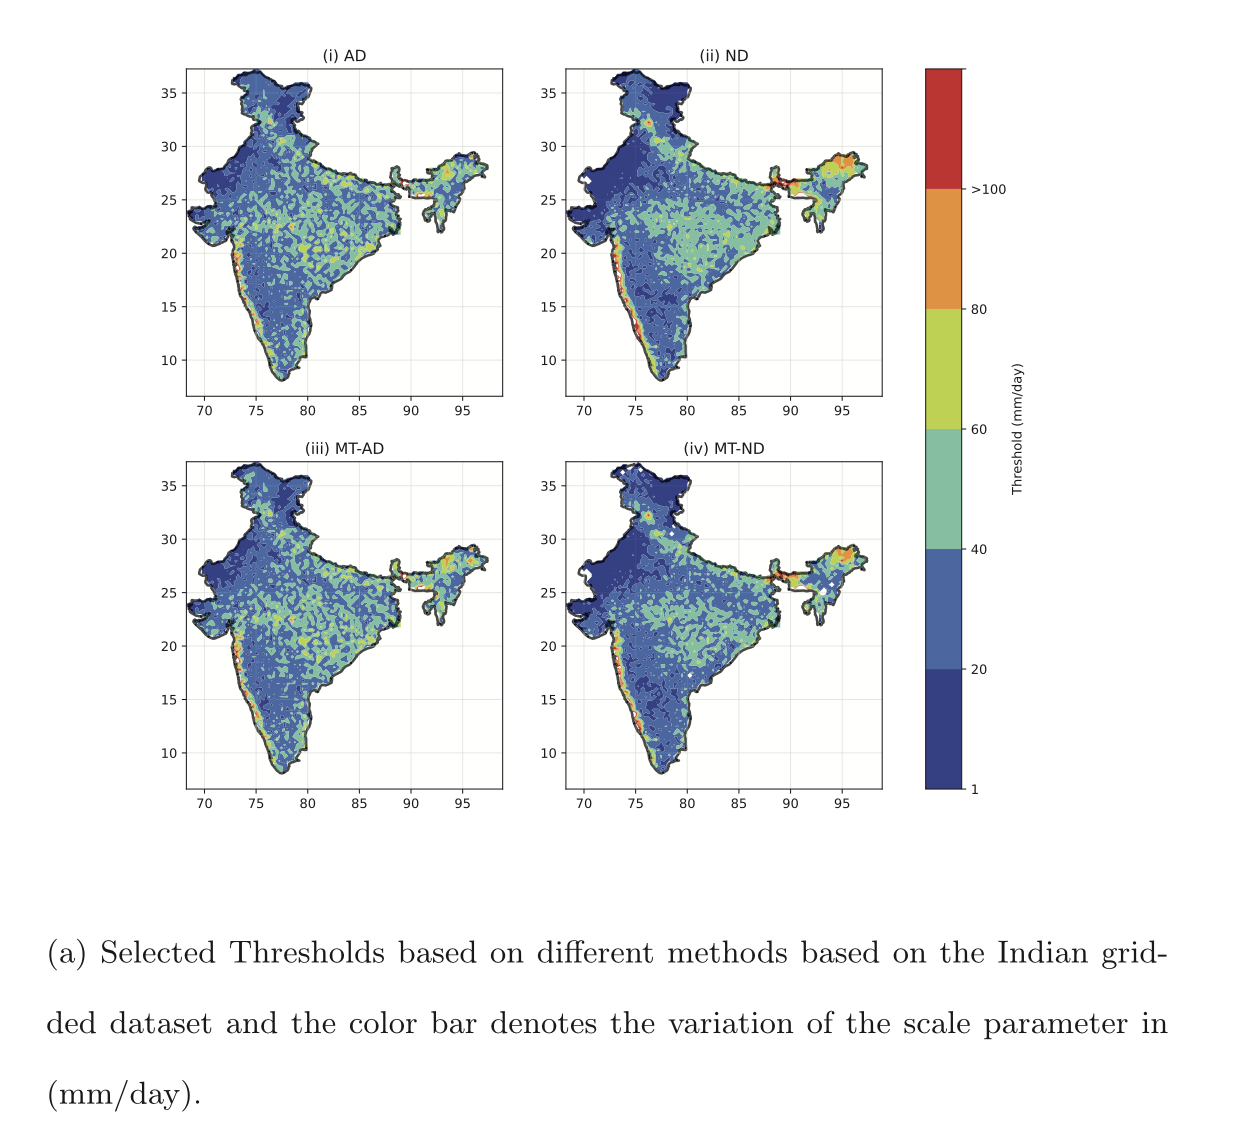

In [117]:
from IPython.display import Image
Image("/Users/kim-wonjin/Documents/CLEWS/Python/Nonlinear/Project/threshold_1.png", width = 700)

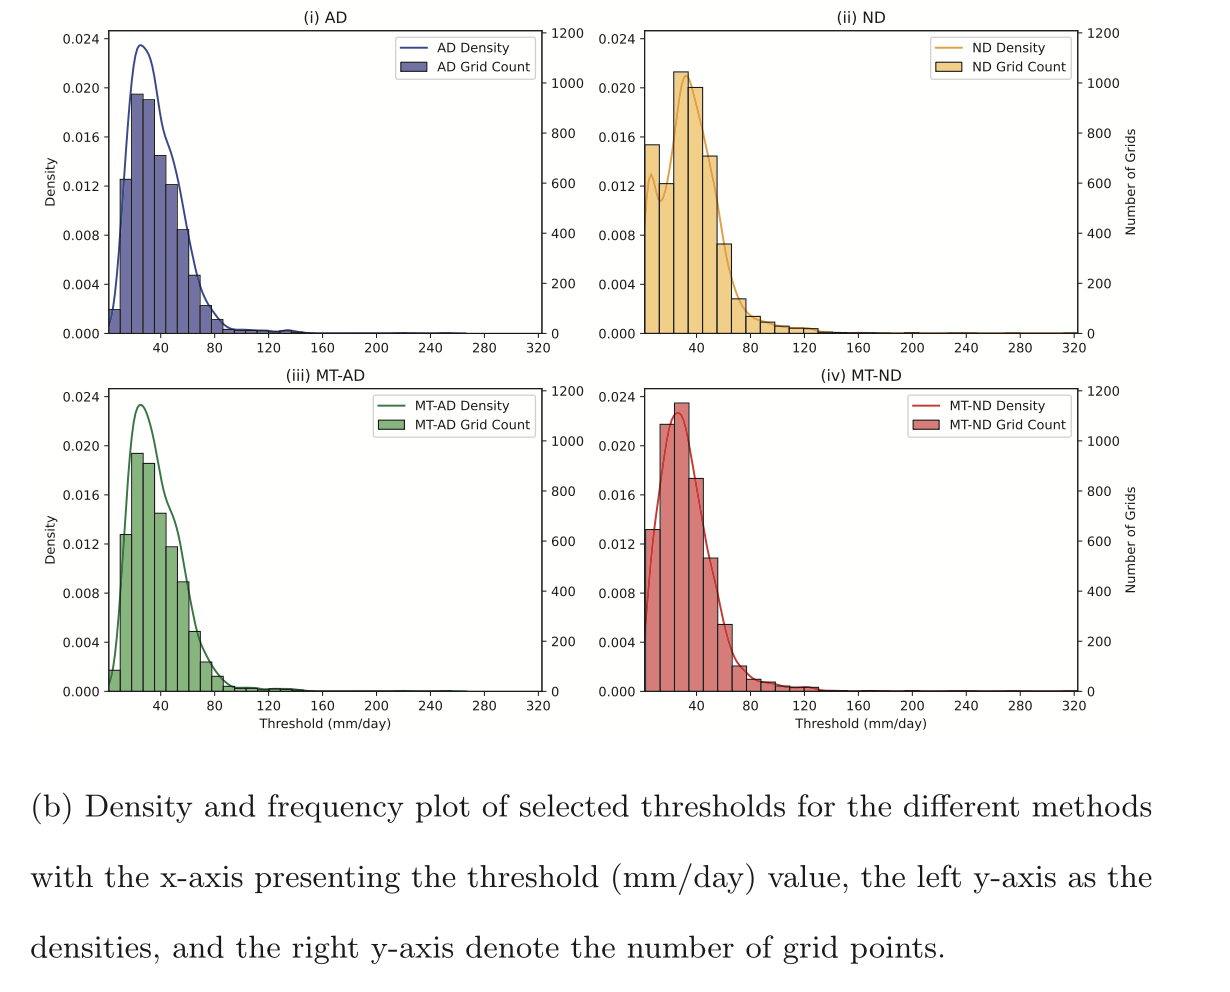

In [118]:
Image("/Users/kim-wonjin/Documents/CLEWS/Python/Nonlinear/Project/threshold_2.png", width = 500)

### 1-3. Threshold classification

### 1-4. EPE(Extreme Precipitation Events) Detection Results using Threshold

## 2. Event Synchronization

## 3. Precipitation Network construction